In [1]:
import os
os.environ["OMP_NUM_THREADS"] = '1'

In [2]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns

In [3]:
iris = load_iris()
x = iris.data
y = iris.target
scaler = StandardScaler()
x_scale  = scaler.fit_transform(x)

<Axes: >

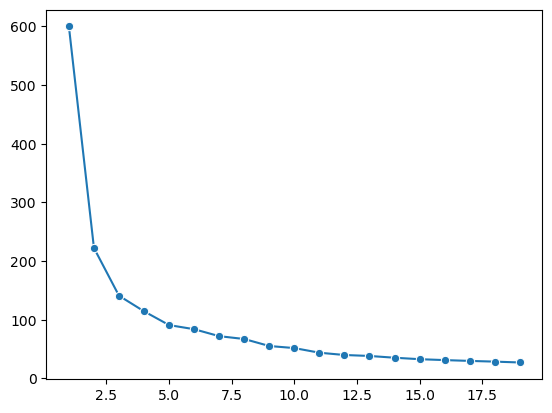

In [4]:
wcss =[]
for k in range(1,20):
    kmeans  = KMeans(n_clusters = k ,random_state =10)
    kmeans.fit(x_scale)
    wcss.append(kmeans.inertia_)

sns.lineplot(x=range(1,20),y=wcss ,marker ="o")



    
    


In [5]:
from kneed import KneeLocator
kl = KneeLocator(range(1,20),wcss,curve = "convex",direction = "decreasing")
print(kl.knee)

3


<Axes: >

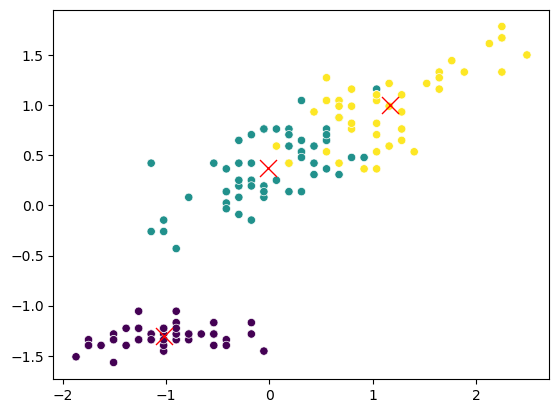

In [16]:
kmeans  = KMeans(n_clusters = 3 )
labels =  kmeans.fit_predict(x_scale)
sns.scatterplot(x=x_scale[:,0],y=x_scale[:,2],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y = kmeans.cluster_centers_[:,2] ,marker = "x",c="red",s=150)